In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

In [2]:
X, y = fetch_openml(
    'mnist_784',
    version = 1,
    return_X_y = True,
    as_frame = False
)

In [4]:
y = y.astype(np.int64)
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (70000, 784)
Shape of y: (70000,)


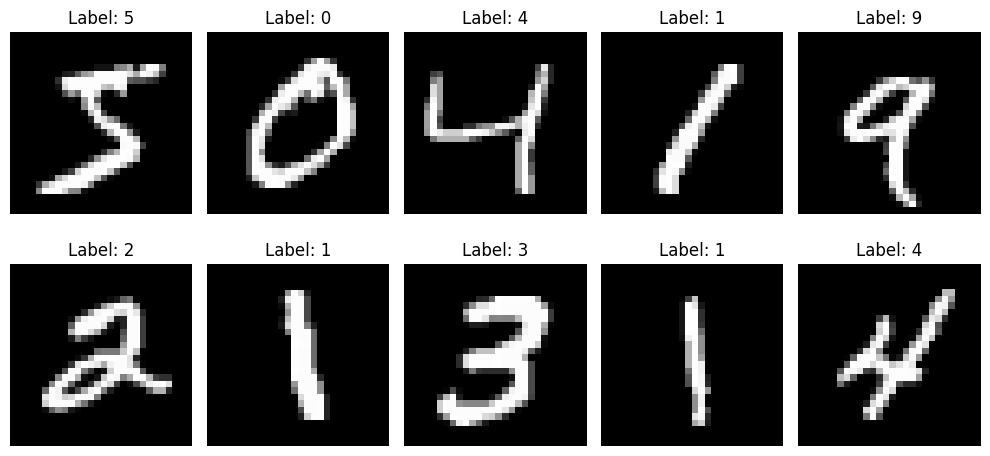

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(10,5))

for i, ax in enumerate(axes.flat):
    ax.imshow(X[i].reshape(28,28), cmap='gray')
    ax.set_title(f"Label: {y[i]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [6]:
X = X/255.0

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=10000,
    random_state=42,
    stratify=y
)

In [8]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train,
    y_train,
    test_size=5000,
    random_state=42,
    stratify=y_train
)

print("Training :", X_train.shape)
print("Validation :", X_valid.shape)
print("Test :", X_test.shape)

Training : (55000, 784)
Validation : (5000, 784)
Test : (10000, 784)


In [10]:
class MLP:
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.01):
        self.learning_rate = learning_rate

        #weights and bias
        self.W1 = np.random.randn(input_size, hidden_size) * 0.01
        self.b1 = np.zeros((1, hidden_size))

        self.W2 = np.random.randn(hidden_size, output_size) * 0.01
        self.b2 = np.zeros((1, output_size))

    # activation function - sigmoid
    def sigmoid(self, z):
        return 1/(1+np.exp(-z))

    def sigmoid_derivative(self, a):
        return a*(1-a)

    def softmax(self, z):
        exp_z = np.exp(z-np.max(z, axis=1, keepdims=True))
        return exp_z/np.sum(exp_z, axis=1, keepdims=True)